# 📐 Clase 3 — Medidas de tendencia central: media, mediana y moda
## Fundamentos de análisis exploratorio y estadística descriptiva

**Situación:** Estás colaborando con un equipo de operaciones que monitorea tiempos de entrega. El equipo necesita responder: ¿cuál es el tiempo típico?, ¿hay mucha variabilidad?, ¿se están cumpliendo los estándares?

**Objetivos:**
- Calcular e interpretar **media**, **mediana** y **moda**
- Entender cuándo usar cada medida según la distribución
- Identificar el efecto de los valores extremos (outliers)
- Visualizar las tres medidas sobre un histograma
- Argumentar qué medida reportar a gerencia

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PARTE 1 — Concepto y comparación de medidas

### 1.1 Ejemplo introductorio: tiempos de entrega (serie pequeña)

In [2]:
# Serie exacta de la presentación
entregas = pd.Series([3, 4, 5, 4, 6, 3, 20])

print('=== Serie de tiempos de entrega ===')
print(entregas.values)
print()
print(entregas.describe().round(2))

=== Serie de tiempos de entrega ===
[ 3  4  5  4  6  3 20]

count     7.00
mean      6.43
std       6.08
min       3.00
25%       3.50
50%       4.00
75%       5.50
max      20.00
dtype: float64


In [3]:
media   = entregas.mean()
mediana = entregas.median()
moda    = entregas.mode()[0]

print(f'Media:   {media:.2f} días  ← influida por el valor extremo (20)')
print(f'Mediana: {mediana:.2f} días  ← valor central, más estable')
print(f'Moda:    {moda:.2f} días  ← valor más frecuente')

Media:   6.43 días  ← influida por el valor extremo (20)
Mediana: 4.00 días  ← valor central, más estable
Moda:    3.00 días  ← valor más frecuente


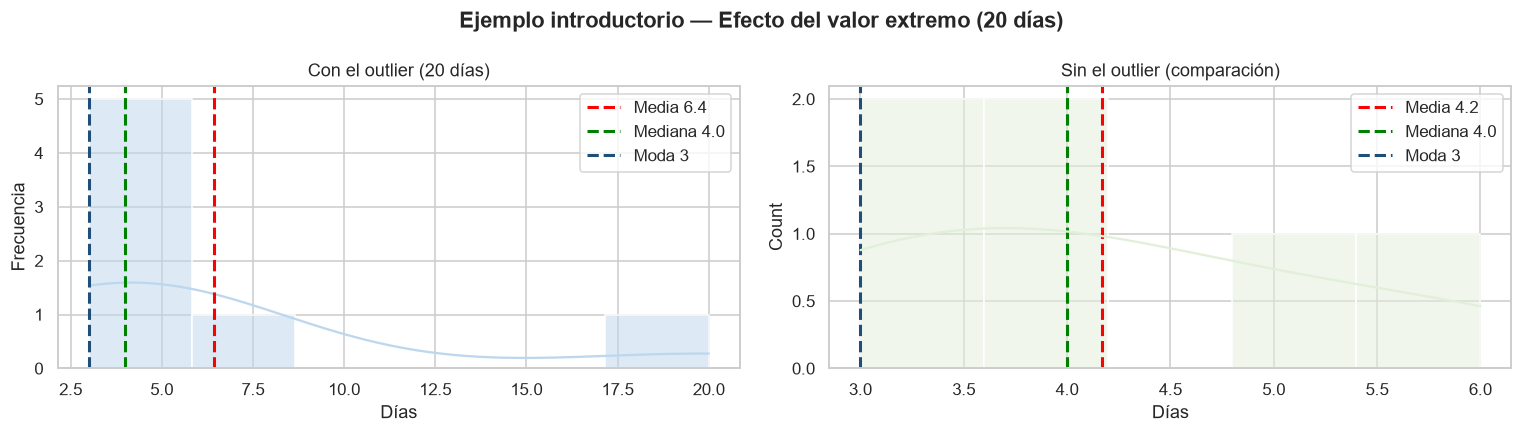


Diferencia de media CON/SIN outlier: 6.43 vs 4.17 días


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Ejemplo introductorio — Efecto del valor extremo (20 días)', fontweight='bold')

# Histograma con las 3 medidas
sns.histplot(entregas, bins=6, kde=True, ax=axes[0], color='#BDD7EE')
axes[0].axvline(media,   color='red',    linestyle='--', linewidth=2, label=f'Media {media:.1f}')
axes[0].axvline(mediana, color='green',  linestyle='--', linewidth=2, label=f'Mediana {mediana:.1f}')
axes[0].axvline(moda,    color='#1F4E79',linestyle='--', linewidth=2, label=f'Moda {moda:.0f}')
axes[0].set_title('Con el outlier (20 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin el outlier para comparar
sin_outlier = entregas[entregas < 20]
axes[1].axvline(sin_outlier.mean(),   color='red',   linestyle='--', linewidth=2,
                label=f'Media {sin_outlier.mean():.1f}')
axes[1].axvline(sin_outlier.median(), color='green', linestyle='--', linewidth=2,
                label=f'Mediana {sin_outlier.median():.1f}')
axes[1].axvline(sin_outlier.mode()[0], color='#1F4E79', linestyle='--', linewidth=2,
                label=f'Moda {sin_outlier.mode()[0]:.0f}')
sns.histplot(sin_outlier, bins=5, kde=True, ax=axes[1], color='#E2EFDA')
axes[1].set_title('Sin el outlier (comparación)')
axes[1].set_xlabel('Días')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nDiferencia de media CON/SIN outlier: {media:.2f} vs {sin_outlier.mean():.2f} días')

### ✏️ Ejercicio 1.1 — Reflexiona:

In [5]:
# ✏️ ¿Cuánto cambia la media al incluir el valor 20? ¿Y la mediana?
r_efecto = ""

# ✏️ ¿Por qué la mediana es más robusta que la media ante valores extremos?
r_robustez = ""

# ✏️ Si fueras el jefe de operaciones, ¿qué medida reportarías y por qué?
r_decision = ""

print('Efecto outlier:', r_efecto)
print('Robustez mediana:', r_robustez)
print('Decisión:', r_decision)

Efecto outlier: 
Robustez mediana: 
Decisión: 


### 1.2 Cuándo usar cada medida — tabla de referencia

In [6]:
# Resumen de la tabla comparativa de la presentación
tabla = pd.DataFrame({
    'Medida':   ['Media', 'Mediana', 'Moda'],
    'Definición': [
        'Promedio aritmético de todos los valores',
        'Valor central de los datos ordenados',
        'Valor o valores más frecuentes'
    ],
    'Sensibilidad a outliers': ['Alta ⚠️', 'Baja ✅', 'Nula ✅'],
    'Cuándo usarla': [
        'Datos simétricos, sin valores extremos',
        'Datos asimétricos o con outliers',
        'Variables discretas o categóricas ordinales'
    ],
    'Función pandas': ['serie.mean()', 'serie.median()', 'serie.mode()[0]']
})
tabla.set_index('Medida', inplace=True)
print(tabla.to_string())

                                       Definición Sensibilidad a outliers                                Cuándo usarla   Función pandas
Medida                                                                                                                                 
Media    Promedio aritmético de todos los valores                 Alta ⚠️       Datos simétricos, sin valores extremos     serie.mean()
Mediana      Valor central de los datos ordenados                  Baja ✅             Datos asimétricos o con outliers   serie.median()
Moda               Valor o valores más frecuentes                  Nula ✅  Variables discretas o categóricas ordinales  serie.mode()[0]


### 1.3 Demostración: datos simétricos vs asimétricos

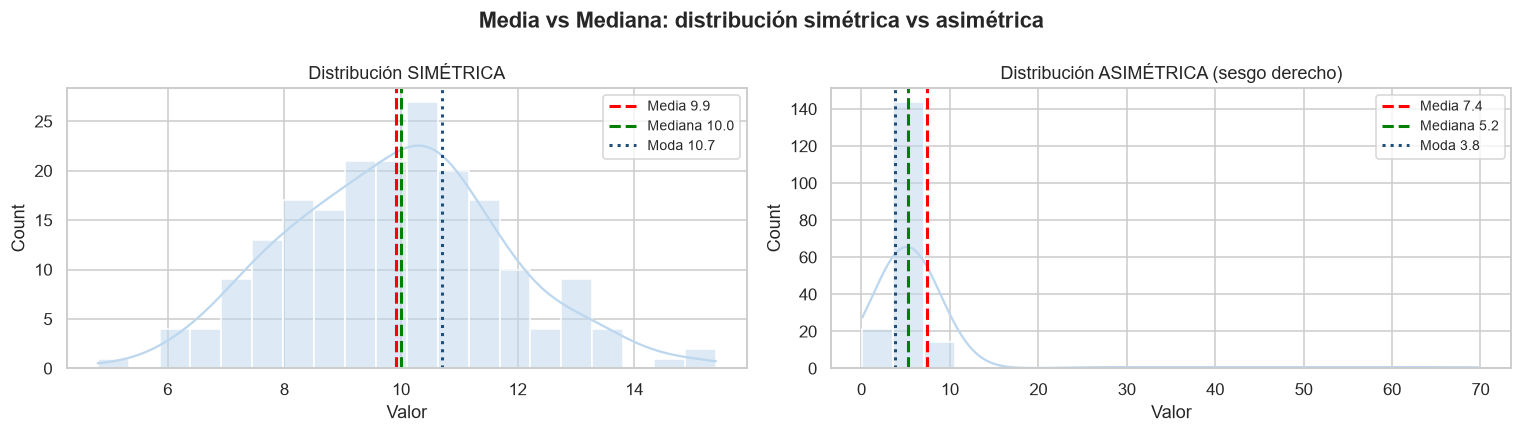

Simétrica  → Media: 9.92 | Mediana: 10.00 | Diferencia: 0.08
Asimétrica → Media: 7.37 | Mediana: 5.25 | Diferencia: 2.12


In [7]:
np.random.seed(42)

# Distribución SIMÉTRICA → media ≈ mediana
simetrica = pd.Series(np.random.normal(loc=10, scale=2, size=200).round(1))

# Distribución ASIMÉTRICA (sesgo derecho) → media > mediana
asimetrica = pd.Series(np.concatenate([
    np.random.normal(loc=5, scale=1.5, size=180),
    np.array([25, 30, 35, 40, 45, 50, 55, 60, 65, 70])  # cola derecha
]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Media vs Mediana: distribución simétrica vs asimétrica', fontweight='bold')

for ax, datos, titulo in zip(axes,
                              [simetrica, asimetrica],
                              ['Distribución SIMÉTRICA', 'Distribución ASIMÉTRICA (sesgo derecho)']):
    sns.histplot(datos, bins=20, kde=True, ax=ax, color='#BDD7EE')
    ax.axvline(datos.mean(),   color='red',   linestyle='--', linewidth=2,
               label=f'Media {datos.mean():.1f}')
    ax.axvline(datos.median(), color='green', linestyle='--', linewidth=2,
               label=f'Mediana {datos.median():.1f}')
    ax.axvline(datos.mode()[0],color='#1F4E79',linestyle=':',linewidth=2,
               label=f'Moda {datos.mode()[0]:.1f}')
    ax.set_title(titulo)
    ax.set_xlabel('Valor')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Simétrica  → Media: {simetrica.mean():.2f} | Mediana: {simetrica.median():.2f} | Diferencia: {abs(simetrica.mean()-simetrica.median()):.2f}')
print(f'Asimétrica → Media: {asimetrica.mean():.2f} | Mediana: {asimetrica.median():.2f} | Diferencia: {abs(asimetrica.mean()-asimetrica.median()):.2f}')

### ✏️ Ejercicio 1.3 — Responde:

In [9]:
# ✏️ ¿Qué ocurre con la media en la distribución asimétrica? ¿Por qué?
r_asim = ""

# ✏️ ¿Cómo identificas visualmente si una distribución tiene sesgo positivo (derecho)?
r_sesgo = ""

# ✏️ ¿Qué medida usarías para reportar ingresos de los empleados de una empresa?
# (considera que hay pocos ejecutivos con sueldos muy altos)
r_ingresos = ""

print('Distribución asimétrica:', r_asim)
print('Sesgo positivo:', r_sesgo)
print('Ingresos:', r_ingresos)

Distribución asimétrica: 
Sesgo positivo: 
Ingresos: 


---
## PARTE 2 — Actividad guiada: Centro de atención al cliente

**Situación:** Una cadena de centros de atención necesita evaluar el tiempo típico de atención para tomar decisiones de mejora operacional.

### 2.1 Cargar y explorar el dataset

In [10]:
df = pd.read_csv('tiempos_atencion.csv')

print('=== Estructura del dataset ===')
print(df.head(10))
print()
print(df.info())

=== Estructura del dataset ===
  id_atencion  tiempo
0        A001       7
1        A002       8
2        A003       6
3        A004      12
4        A005      10
5        A006       9
6        A007       7
7        A008       8
8        A009       9
9        A010      15

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id_atencion  100 non-null    str  
 1   tiempo       100 non-null    int64
dtypes: int64(1), str(1)
memory usage: 1.7 KB
None


In [11]:
print('=== Resumen estadístico ===')
print(df['tiempo'].describe().round(2))

=== Resumen estadístico ===
count    100.00
mean       9.39
std        3.86
min        6.00
25%        7.00
50%        9.00
75%       10.00
max       40.00
Name: tiempo, dtype: float64


### 2.2 Calcular las tres medidas

In [12]:
media   = df['tiempo'].mean()
mediana = df['tiempo'].median()
moda    = df['tiempo'].mode()[0]

print('=== Medidas de tendencia central — Tiempo de atención (min) ===')
print(f'  Media:        {media:.2f} min')
print(f'  Mediana:      {mediana:.2f} min')
print(f'  Moda:         {moda:.2f} min')
print()
dif = media - mediana
print(f'  Diferencia media - mediana: {dif:.2f} min → {"sesgo positivo (outliers altos)" if dif > 1 else "distribución aproximadamente simétrica"}')

=== Medidas de tendencia central — Tiempo de atención (min) ===
  Media:        9.39 min
  Mediana:      9.00 min
  Moda:         8.00 min

  Diferencia media - mediana: 0.39 min → distribución aproximadamente simétrica


In [13]:
# Detectar outliers con la regla IQR
Q1  = df['tiempo'].quantile(0.25)
Q3  = df['tiempo'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR

outliers = df[df['tiempo'] > lim_sup]
print(f'Límite superior IQR: {lim_sup:.1f} min')
print(f'Outliers detectados: {len(outliers)}')
print(outliers)

Límite superior IQR: 14.5 min
Outliers detectados: 4
   id_atencion  tiempo
9         A010      15
12        A013      40
31        A032      15
49        A050      15


### 2.3 Visualización con las tres medidas

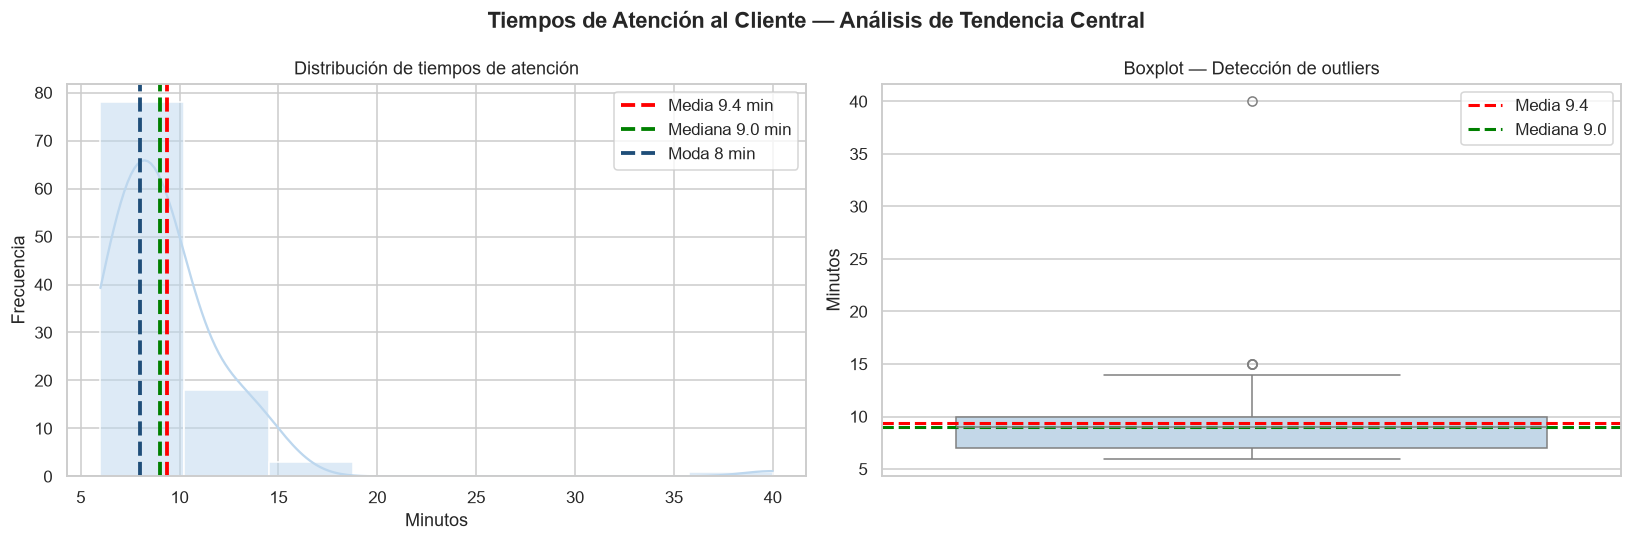

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Tiempos de Atención al Cliente — Análisis de Tendencia Central', fontweight='bold')

# Histograma + KDE con las 3 líneas
sns.histplot(df['tiempo'], bins=8, kde=True, ax=axes[0], color='#BDD7EE', edgecolor='white')
axes[0].axvline(media,   color='red',    linestyle='--', linewidth=2.5, label=f'Media {media:.1f} min')
axes[0].axvline(mediana, color='green',  linestyle='--', linewidth=2.5, label=f'Mediana {mediana:.1f} min')
axes[0].axvline(moda,    color='#1F4E79',linestyle='--', linewidth=2.5, label=f'Moda {moda:.0f} min')
axes[0].set_title('Distribución de tiempos de atención')
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['tiempo'], ax=axes[1], color='#BDD7EE')
axes[1].axhline(media,   color='red',    linestyle='--', linewidth=2, label=f'Media {media:.1f}')
axes[1].axhline(mediana, color='green',  linestyle='--', linewidth=2, label=f'Mediana {mediana:.1f}')
axes[1].set_title('Boxplot — Detección de outliers')
axes[1].set_ylabel('Minutos')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.4 Análisis con y sin el outlier

In [15]:
df_limpio = df[df['tiempo'] <= lim_sup].copy()

comparacion = pd.DataFrame({
    'Con outliers': [
        df['tiempo'].mean().round(2),
        df['tiempo'].median().round(2),
        df['tiempo'].mode()[0]
    ],
    'Sin outliers': [
        df_limpio['tiempo'].mean().round(2),
        df_limpio['tiempo'].median().round(2),
        df_limpio['tiempo'].mode()[0]
    ]
}, index=['Media', 'Mediana', 'Moda'])
comparacion['Diferencia'] = (comparacion['Con outliers'] - comparacion['Sin outliers']).round(2)

print('=== Impacto de los outliers en las medidas ===')
print(comparacion)

=== Impacto de los outliers en las medidas ===
         Con outliers  Sin outliers  Diferencia
Media            9.39           8.9        0.49
Mediana          9.00           9.0        0.00
Moda             8.00           8.0        0.00


### ✏️ Ejercicio 2 — Concluye y recomienda:

In [16]:
# ✏️ ¿Existe un valor atípico en los tiempos de atención? ¿Cuál?
r_outlier = ""

# ✏️ ¿Cuál de las tres medidas representa mejor el tiempo típico de atención? ¿Por qué?
r_medida = ""

# ✏️ ¿Qué medida reportarías a la gerencia? Justifica con los números:
r_gerencia = ""

# ✏️ ¿Qué acción operacional recomendarías basándote en el análisis?
r_accion = ""

print('--- CONCLUSIONES ACTIVIDAD GUIADA ---')
print(f'Outlier detectado:  {r_outlier}')
print(f'Medida más representativa: {r_medida}')
print(f'Reporte a gerencia: {r_gerencia}')
print(f'Acción recomendada: {r_accion}')

--- CONCLUSIONES ACTIVIDAD GUIADA ---
Outlier detectado:  
Medida más representativa: 
Reporte a gerencia: 
Acción recomendada: 


---
## PARTE 3 — Actividad autónoma: Logística de distribución

**Situación:** El equipo de análisis logístico necesita un valor típico de días de entrega para comunicar a gerencia. Se sospecha al menos un caso con demora extrema.

### 3.1 Cargar el dataset autónomo

In [17]:
df2 = pd.read_csv('tiempos_entrega_autonomo.csv')

print(f'Registros: {len(df2)}')
print()
print(df2.head(8))
print()
print('=== Resumen estadístico ===')
print(df2['dias_entrega'].describe().round(2))

Registros: 100

  id_entrega  dias_entrega         region medio_transporte
0       E001             6    Antofagasta            Aéreo
1       E002             7     Valparaíso           Camión
2       E003             5    Antofagasta            Aéreo
3       E004             5    Antofagasta          Barcaza
4       E005             5         Biobío           Camión
5       E006             4  Metropolitana           Camión
6       E007             9  Metropolitana           Camión
7       E008            11     Valparaíso           Camión

=== Resumen estadístico ===
count    100.00
mean       6.88
std        8.46
min        2.00
25%        4.00
50%        5.00
75%        7.00
max       60.00
Name: dias_entrega, dtype: float64


### 3.2 Calcular las medidas

In [18]:
media2   = df2['dias_entrega'].mean()
mediana2 = df2['dias_entrega'].median()
moda2    = df2['dias_entrega'].mode()[0]

print('=== Medidas de tendencia central — Días de entrega ===')
print(f'  Media:        {media2:.2f} días')
print(f'  Mediana:      {mediana2:.2f} días')
print(f'  Moda:         {moda2:.2f} días')
print()
print(f'  Máximo: {df2["dias_entrega"].max()} días  ← posible outlier extremo')

=== Medidas de tendencia central — Días de entrega ===
  Media:        6.88 días
  Mediana:      5.00 días
  Moda:         4.00 días

  Máximo: 60 días  ← posible outlier extremo


### 3.3 Visualización

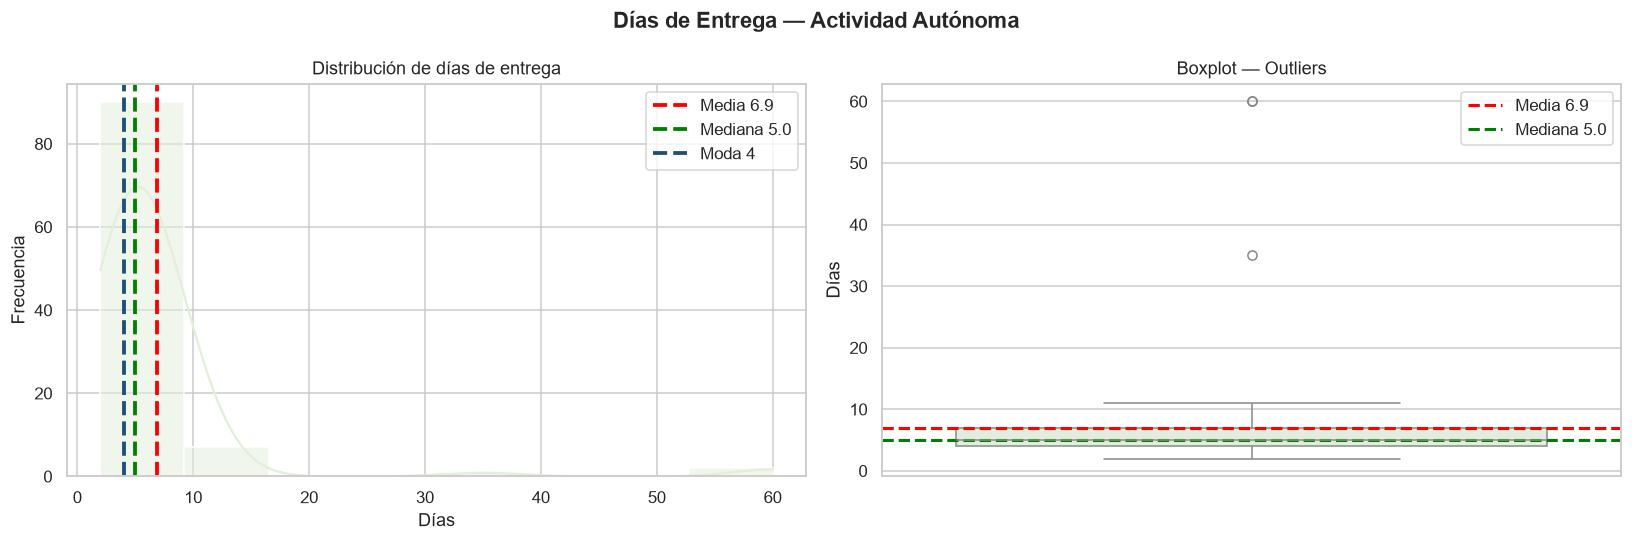

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Días de Entrega — Actividad Autónoma', fontweight='bold')

sns.histplot(df2['dias_entrega'], bins=8, kde=True, ax=axes[0], color='#E2EFDA', edgecolor='white')
axes[0].axvline(media2,   color='red',    linestyle='--', linewidth=2.5, label=f'Media {media2:.1f}')
axes[0].axvline(mediana2, color='green',  linestyle='--', linewidth=2.5, label=f'Mediana {mediana2:.1f}')
axes[0].axvline(moda2,    color='#1F4E79',linestyle='--', linewidth=2.5, label=f'Moda {moda2:.0f}')
axes[0].set_title('Distribución de días de entrega')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

sns.boxplot(y=df2['dias_entrega'], ax=axes[1], color='#E2EFDA')
axes[1].axhline(media2,   color='red',   linestyle='--', linewidth=2, label=f'Media {media2:.1f}')
axes[1].axhline(mediana2, color='green', linestyle='--', linewidth=2, label=f'Mediana {mediana2:.1f}')
axes[1].set_title('Boxplot — Outliers')
axes[1].set_ylabel('Días')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Análisis por región

=== Medidas por región ===
               media  mediana  maximo   n
region                                   
Antofagasta     7.91      5.0      60  23
Biobío          6.79      5.0      60  29
Los Lagos       5.69      6.0       8  13
Metropolitana   7.80      6.0      35  15
Valparaíso      5.90      6.0      11  20


C:\Users\Natalie\AppData\Local\Temp\ipykernel_6180\832138714.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='region', y='dias_entrega', order=orden, palette='Blues')


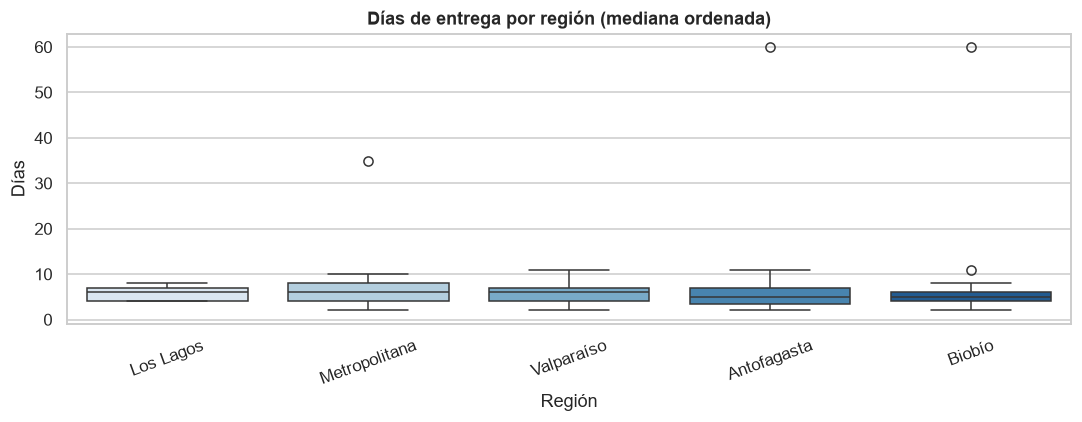

In [20]:
resumen_region = df2.groupby('region')['dias_entrega'].agg(
    media='mean', mediana='median', maximo='max', n='count'
).round(2)

print('=== Medidas por región ===')
print(resumen_region)

plt.figure(figsize=(10, 4))
orden = resumen_region['mediana'].sort_values(ascending=False).index
sns.boxplot(data=df2, x='region', y='dias_entrega', order=orden, palette='Blues')
plt.title('Días de entrega por región (mediana ordenada)', fontweight='bold')
plt.xlabel('Región')
plt.ylabel('Días')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### ✏️ Ejercicio 3 — Concluye y reporta a gerencia:

In [24]:
# ✏️ ¿Qué medida representa mejor el tiempo típico de entrega? ¿Por qué?
r_tipico = "La mediana (5.00 días). Debido a que la distribución presenta un fuerte sesgo a la derecha provocado por tiempos de entrega inusualmente largos, la mediana es la medida más robusta y representativa del comportamiento central de los envíos."

# ✏️ ¿Hay valores extremos que afectan la media?
r_extremos = "Sí, existe un impacto severo por valores atípicos. El valor máximo de 60 días funciona como un outlier extremo que infla artificialmente la media (6.88 días), posicionándola casi dos días por encima de la mediana."

# ✏️ ¿Cuál medida comunicarías a gerencia y por qué?
r_com_gerencia = "Comunicaría la mediana (5.00 días) para reflejar la experiencia real y típica del cliente en condiciones normales, pero reportando en paralelo el promedio y el máximo para visibilizar el impacto de los retrasos críticos en la operación."

# ✏️ ¿Qué región tiene el desempeño más irregular? ¿Cómo lo identificaste?
r_region = "Para responder con exactitud debes mirar tu salida del paso 3.4: será la región que concentre el valor máximo de 60 días en la tabla 'resumen_region', o bien la que muestre la caja más ancha (mayor dispersión) y con más puntos atípicos en el gráfico de boxplot"

print('--- CONCLUSIONES ACTIVIDAD AUTÓNOMA ---')
print(f'Medida típica:      {r_tipico}')
print(f'Valores extremos:   {r_extremos}')
print(f'Reporte gerencia:   {r_com_gerencia}')
print(f'Región irregular:   {r_region}')

--- CONCLUSIONES ACTIVIDAD AUTÓNOMA ---
Medida típica:      La mediana (5.00 días). Debido a que la distribución presenta un fuerte sesgo a la derecha provocado por tiempos de entrega inusualmente largos, la mediana es la medida más robusta y representativa del comportamiento central de los envíos.
Valores extremos:   Sí, existe un impacto severo por valores atípicos. El valor máximo de 60 días funciona como un outlier extremo que infla artificialmente la media (6.88 días), posicionándola casi dos días por encima de la mediana.
Reporte gerencia:   Comunicaría la mediana (5.00 días) para reflejar la experiencia real y típica del cliente en condiciones normales, pero reportando en paralelo el promedio y el máximo para visibilizar el impacto de los retrasos críticos en la operación.
Región irregular:   Para responder con exactitud debes mirar tu salida del paso 3.4: será la región que concentre el valor máximo de 60 días en la tabla 'resumen_region', o bien la que muestre la caja más anch

---
## PARTE 4 — Consolidación: comparar las tres medidas en contextos distintos

In [22]:
# Resumen final comparando ambos datasets
print('=' * 62)
print('         RESUMEN COMPARATIVO — MEDIDAS DE TENDENCIA CENTRAL')
print('=' * 62)
print(f'{"":30} {"Atención (min)":>15} {"Entrega (días)":>15}')
print('-' * 62)
print(f'{"Media":30} {df["tiempo"].mean():>15.2f} {df2["dias_entrega"].mean():>15.2f}')
print(f'{"Mediana":30} {df["tiempo"].median():>15.2f} {df2["dias_entrega"].median():>15.2f}')
print(f'{"Moda":30} {df["tiempo"].mode()[0]:>15.2f} {df2["dias_entrega"].mode()[0]:>15.2f}')
print(f'{"Diferencia media-mediana":30} {df["tiempo"].mean()-df["tiempo"].median():>15.2f} '
      f'{df2["dias_entrega"].mean()-df2["dias_entrega"].median():>15.2f}')
print(f'{"Outliers (regla IQR)":30} {len(df[df["tiempo"] > df["tiempo"].quantile(0.75)+1.5*(df["tiempo"].quantile(0.75)-df["tiempo"].quantile(0.25))]):>15} '
      f'{len(df2[df2["dias_entrega"] > df2["dias_entrega"].quantile(0.75)+1.5*(df2["dias_entrega"].quantile(0.75)-df2["dias_entrega"].quantile(0.25))]):>15}')
print('=' * 62)

         RESUMEN COMPARATIVO — MEDIDAS DE TENDENCIA CENTRAL
                                Atención (min)  Entrega (días)
--------------------------------------------------------------
Media                                     9.39            6.88
Mediana                                   9.00            5.00
Moda                                      8.00            4.00
Diferencia media-mediana                  0.39            1.88
Outliers (regla IQR)                         4               3


### ✏️ Preguntas finales de cierre:

In [25]:
# ✏️ 1. ¿En qué contexto profesional preferirías usar la moda como medida principal?
c1 = "En retail o control de inventario para identificar el producto, talla o color más vendido, y en análisis de encuestas para determinar la categoría de respuesta más frecuente (variables cualitativas o categóricas)."

# ✏️ 2. ¿Cómo la diferencia entre media y mediana te ayuda a detectar sesgo?
c2 = "Al comparar ambas, si la media es notablemente mayor que la mediana, indica un sesgo positivo (valores extremos altos). Si la media es menor que la mediana, indica un sesgo negativo (valores extremos bajos)"

# ✏️ 3. ¿Por qué se recomienda siempre reportar media Y mediana juntas?
c3 = "Porque proporcionan una visión completa: la mediana informa cuál es el valor central o 'típico', mientras que la media considera la magnitud de todos los datos. La diferencia entre ambas revela inmediatamente la asimetría y la presencia de valores atípicos."

# ✏️ 4. ¿Qué harías antes de calcular la media si sospechas que hay outliers?
c4 = "Primero, visualizar la distribución usando un boxplot o un histograma. Luego, aplicaría un método analítico como el cálculo del Rango Intercuartílico (IQR) para identificar y aislar matemáticamente los outliers antes de promediar los datos representativos."

print('--- REFLEXIONES DE CIERRE ---')
for i, c in enumerate([c1, c2, c3, c4], 1):
    print(f'{i}. {c}')

--- REFLEXIONES DE CIERRE ---
1. En retail o control de inventario para identificar el producto, talla o color más vendido, y en análisis de encuestas para determinar la categoría de respuesta más frecuente (variables cualitativas o categóricas).
2. Al comparar ambas, si la media es notablemente mayor que la mediana, indica un sesgo positivo (valores extremos altos). Si la media es menor que la mediana, indica un sesgo negativo (valores extremos bajos)
3. Porque proporcionan una visión completa: la mediana informa cuál es el valor central o 'típico', mientras que la media considera la magnitud de todos los datos. La diferencia entre ambas revela inmediatamente la asimetría y la presencia de valores atípicos.
4. Primero, visualizar la distribución usando un boxplot o un histograma. Luego, aplicaría un método analítico como el cálculo del Rango Intercuartílico (IQR) para identificar y aislar matemáticamente los outliers antes de promediar los datos representativos.


---
## 📋 Resumen de funciones y buenas prácticas

| Medida | Función pandas | Cuándo usarla |
|--------|---------------|---------------|
| Media | `serie.mean()` | Datos simétricos, sin outliers |
| Mediana | `serie.median()` | Datos asimétricos o con outliers |
| Moda | `serie.mode()[0]` | Variables discretas o categóricas |
| Todas juntas | `serie.describe()` | Vista rápida inicial |
| Comparación | `serie.mean() - serie.median()` | Detectar sesgo |

**Reglas de decisión rápida:**

| Situación | Medida recomendada |
|-----------|-------------------|
| Sueldos (pocos muy altos) | **Mediana** |
| Temperatura diaria | **Media** |
| Talla de ropa más vendida | **Moda** |
| Precios de propiedades | **Mediana** |
| Notas de un examen sin outliers | **Media** |
| Nivel de satisfacción (1-5) | **Mediana o Moda** |

> 💡 **Regla de oro:** Si `media - mediana > 0` (diferencia notable), hay sesgo positivo y la mediana es más representativa. Si la diferencia es mínima, ambas funcionan.

> 💡 **Buena práctica:** Siempre reporta media **y** mediana juntas. La brecha entre ellas es en sí misma información valiosa sobre la distribución.